Hồi quy LOGISTIC

>


BINARY LOGISTIC REGRESSION

In [1]:
#duongDan = '\C:\CNTT\AI\Machine_Learning\Practice\data\ex2data1.txt' # 

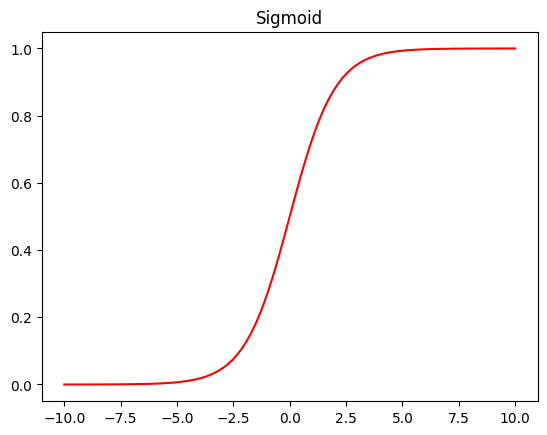

In [2]:
import numpy as np
from matplotlib import pyplot

def sigmoid(z):
  return 1/(1 + np.exp(-z))

nums = np.linspace(-10, 10, 100)
fig, ax = pyplot.subplots()
ax.plot(nums, sigmoid(nums), 'r')
ax.set_title('Sigmoid')
pyplot.show()

Data và Bài toán

In [3]:
#import csv
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot

In [4]:
path = os.getcwd() + '/data/ex2data1.txt'

In [5]:
tenCot = ['Exam 1', 'Exam 2', 'Admitted']
duLieu = pd.read_csv(path, names = tenCot)

print(duLieu.shape)

(100, 3)


In [6]:
print(duLieu.head())

      Exam 1     Exam 2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1


In [7]:
print(duLieu.describe())

           Exam 1      Exam 2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


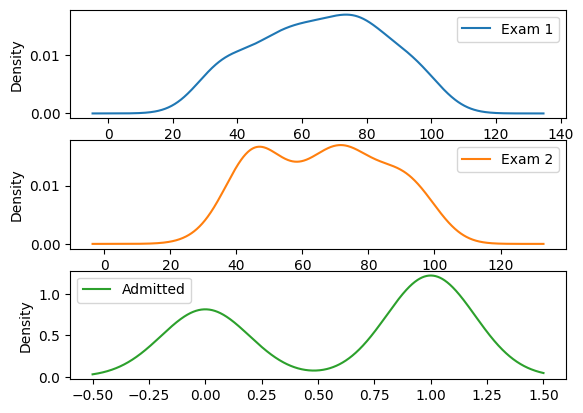

In [8]:
duLieu.plot(kind = 'density', subplots = True, sharex = False)
pyplot.show()

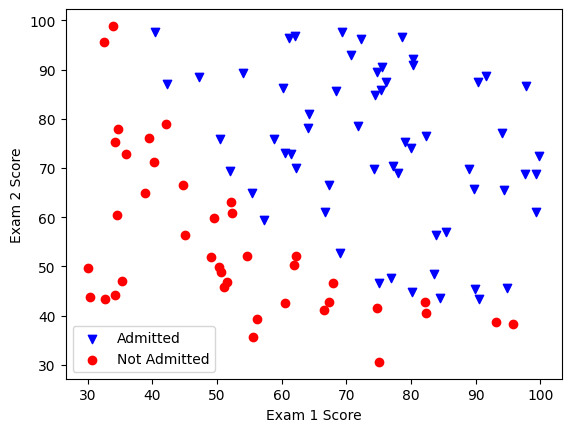

In [9]:
def doThi():
  do = duLieu[duLieu['Admitted'].isin([1])]
  truot = duLieu[duLieu['Admitted'].isin([0])]
  fig, ax = pyplot.subplots()
  ax.scatter(do['Exam 1'], do['Exam 2'], c='b', marker='v', label= 'Admitted')
  ax.scatter(truot['Exam 1'], truot['Exam 2'], c='r', marker='o', label='Not Admitted')
  ax.legend()
  ax.set_xlabel('Exam 1 Score')
  ax.set_ylabel('Exam 2 Score')
  pyplot.show()
doThi()

Hàm chi phí và Gradient descent

In [10]:
maTran = duLieu.values
m,n = maTran.shape
X_cacCot = maTran[:, 0:n-1]
X = np.insert(X_cacCot, 0, values = 1, axis = 1)
Y = maTran[:,n-1:n]

print(X[:5])  # in ra 5 dòng đầu của X
print("\n")
print(X[:5])  # in ra 5 dòng đầu của Y

[[ 1.         34.62365962 78.02469282]
 [ 1.         30.28671077 43.89499752]
 [ 1.         35.84740877 72.90219803]
 [ 1.         60.18259939 86.3085521 ]
 [ 1.         79.03273605 75.34437644]]


[[ 1.         34.62365962 78.02469282]
 [ 1.         30.28671077 43.89499752]
 [ 1.         35.84740877 72.90219803]
 [ 1.         60.18259939 86.3085521 ]
 [ 1.         79.03273605 75.34437644]]


In [11]:
theta = np.zeros((1, X.shape[1]))
print(theta)
print("\n")
print(X.shape, Y.shape, theta.shape)

[[0. 0. 0.]]


(100, 3) (100, 1) (1, 3)


In [12]:
def computeCost(theta, X, Y):
  theta = np.matrix(theta)
  h_theta = sigmoid(np.dot(X, theta.T))
  first = np.multiply(-Y, np.log(h_theta))
  second = np.multiply((1 - Y), np.log(1 - h_theta))
  return np.sum(first - second) / (len(X))

print(computeCost(theta, X, Y))
# in ra chi phi ban đầu

0.6931471805599453


Thuật toán Gradient descent

In [13]:
def gradientDescent(theta, X, Y):
  theta = np.matrix(theta)
  X = np.matrix(X)
  Y = np.matrix(Y)

  parameters = theta.shape[1]
  grad = np.zeros(parameters)

  error = sigmoid(np.dot(X, theta.T)) -Y

  for i in range(parameters):
    term = np.multiply(error, X[:,i])
    grad[i] = np.sum(term) / len(X)  #len(X)=m
  return grad

print(gradientDescent(theta, X, Y))
print("\n")
# in ra result đạo hàm
import scipy.optimize as opt
result = opt.fmin_tnc(func = computeCost, x0 = theta, fprime = gradientDescent, args = (X, Y))
print(result)


[ -0.1        -12.00921659 -11.26284221]


(array([-25.16131865,   0.20623159,   0.20147149]), 36, 0)


In [14]:
theta_sauCung = result[0]
print(theta_sauCung)

print(computeCost(theta_sauCung, X, Y))

[-25.16131865   0.20623159   0.20147149]
0.20349770158947447


In [15]:
def predict(theta, X):
  probability = sigmoid(np.dot(X,theta.T))
  return [1 if x >= 0.5
            else 0 for x in probability]

In [16]:
predictions = predict(theta_sauCung, X)
soLanDoanDung = [1 if ((a == 1 and b == 1) or (a == 0 and b == 0))
                   else 0 for (a, b) in zip(predictions, Y)]
doChinhXac = (sum(map(int, soLanDoanDung)) / len(predictions) * 100) # Y == predictions == soLanDoanDung
print('Do chinh xac = {0:.2f}%'.format(doChinhXac))

Do chinh xac = 89.00%


In [17]:
print(Y)

[[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


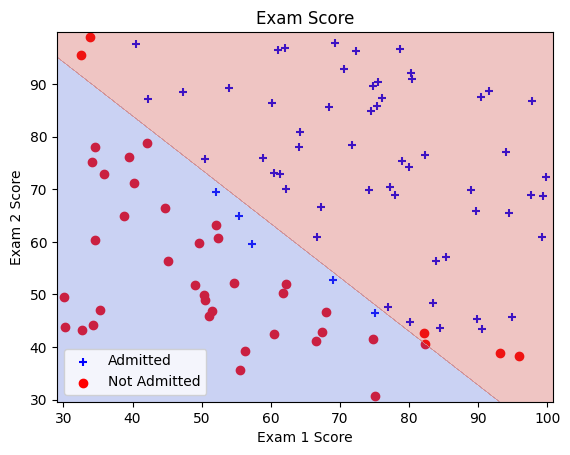

In [19]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def plot_decision_boundary(X, y, model, ax):
    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

def doThi_fid():
    # Assuming duLieu is your DataFrame containing 'Exam 1', 'Exam 2', and 'Admitted' columns
    do = duLieu[duLieu['Admitted'].isin([1])]
    truot = duLieu[duLieu['Admitted'].isin([0])]

    # Scatter plot
    fig, ax = plt.subplots()
    ax.scatter(do['Exam 1'], do['Exam 2'], c='b', marker='+', label='Admitted')
    ax.scatter(truot['Exam 1'], truot['Exam 2'], c='r', marker='o', label='Not Admitted')
    ax.legend()
    ax.set_xlabel('Exam 1 Score')
    ax.set_ylabel('Exam 2 Score')
    ax.set_title('Exam Score')

    # Prepare data for training the logistic regression model
    X = duLieu[['Exam 1', 'Exam 2']].values
    Y = duLieu['Admitted'].values

    # Train logistic regression model
    model = LogisticRegression()
    model.fit(X, Y)

    # Plot decision boundary
    plot_decision_boundary(X, Y, model, ax)

    plt.show()

doThi_fid()
